In [13]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

Autosaving every 300 seconds


In [14]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse import spdiags
import sympy as sy
from numpy import linspace, ones
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.pylab import *
from time import time
from mpl_toolkits import mplot3d


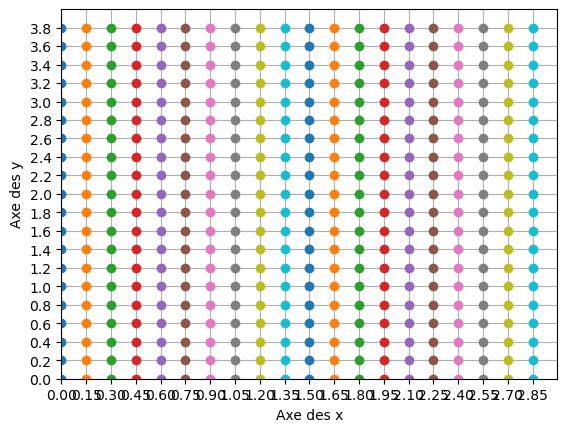

In [15]:
L = 3
H = 4
Nx = 20
Ny = 20
dx=L/(Nx)
dy=H/(Ny)
x=linspace(0,L-dx,Nx)
y=linspace(0,H-dy,Ny)

inconnues_x, inconnues_y = np.meshgrid(x, y)
plt.xlim(0,L)
plt.ylim(0,H)
plt.plot(inconnues_x, inconnues_y, 'o')

# Ajouter des labels
xlabel('Axe des x')
ylabel('Axe des y')
xticks(np.arange(0, L, dx))
yticks(np.arange(0, H, dy))
grid(True)

plt.show()

In [16]:
def Matrix_A(Nx, Ny):
    # grille pour Dirichlet bord haut et droit.
    # Neumann pour bord gauche et bas
    
    dx=L/(Nx)
    dy=H/(Ny)
    
    #liste des numéros des noeuds presentants 4 voisins faisant partie des noeuds où la solution est inconnue
    Linterieur = []
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            Linterieur.append(i + j*Nx)
            
    
    #liste des noeuds du bas sauf coins
    Lbas=[i for i in range(1,Nx-1)]
    #liste des noeuds du haut sauf coins
    Lhaut=[i for i in range(Nx*(Ny-1)+1,Nx*Ny-1)]
    #liste des noeuds de gauche sauf coins
    Lgauche=[i*Nx for i in range(1,Ny-1)]
    #liste des noeuds de droite sauf coins
    Ldroite=[i*Nx-1 for i in range(2,Ny)]
    
    
    A=lil_matrix((Nx*Ny,Nx*Ny))
    #construction de la diagonale de A
    for k in range(Nx*Ny):
        A[k,k]=2/dx**2+2/dy**2
    #construction de la matrice A pour les noeuds presentants 4 voisins inconnus
    for k in Linterieur:
        A[k,k+1]=-1/dx**2
        A[k,k-1]=-1/dx**2
        A[k,k+Nx]=-1/dy**2
        A[k,k-Nx]=-1/dy**2
    # contribution pour les noeuds du bas
    for k in Lbas:
        A[k,k+1]=-1/dx**2
        A[k,k-1]=-1/dx**2
        A[k,k+Nx]=-2/dy**2
    # contribution pour les noeuds du haut
    for k in Lhaut:
        A[k,k+1]=-1/dx**2
        A[k,k-1]=-1/dx**2
        A[k,k-Nx]=-1/dy**2
    # contribution pour les noeuds de gauche
    for k in Lgauche:
        A[k,k+1]=-2/dx**2
        A[k,k+Nx]=-1/dy**2
        A[k,k-Nx]=-1/dy**2
    # contribution pour les noeuds de droite
    for k in Ldroite:
        A[k,k-1]=-1/dx**2
        A[k,k+Nx]=-1/dy**2
        A[k,k-Nx]=-1/dy**2
    #coin bas gauche
    k=0
    A[k,k+1]=-2/dx**2
    A[k,k+Nx]=-2/dy**2
    #coin bas droite
    k=Nx-1
    A[k,k-1]=-1/dx**2
    A[k,k+Nx]=-2/dy**2
    #coin haut gauche
    k=Nx*(Ny-1)
    A[k,k+1]=-2/dx**2
    A[k,k-Nx]=-1/dy**2
    #coin haut droite
    k=Nx*Ny-1
    A[k,k-1]=-1/dx**2
    A[k,k-Nx]=-1/dy**2
    
    #A = csr_matrix(A)
    


    return A.tocsr()


In [17]:
def Matrix_f(Nx, Ny, X, Y, F):
    dx=L/(Nx)
    dy=H/(Ny)
    matrice = []
    for j in range(len(Y)):
        for i in range(len(X)):
            matrice.append([F(X[i],Y[j])])
    
    return np.array(matrice)

In [18]:
def F(x, y):
    return -1
def Approx(Nx, Ny, X, Y, F):
    return spsolve(Matrix_A(Nx, Ny).astype(np.float64), Matrix_f(Nx, Ny, X, Y, F).astype(np.float64))

AttributeError: 'ImmutableDenseNDimArray' object has no attribute 'as_coefficient'

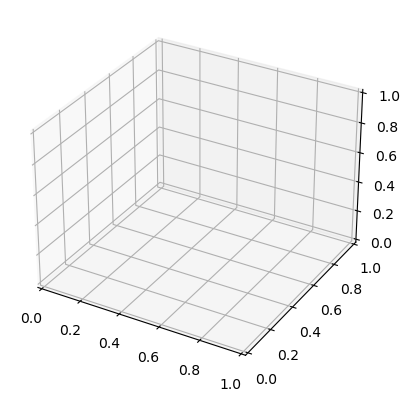

In [25]:
#U = Approx(Nx, Ny, x, y, F)
#uu=U.reshape((Ny,Nx))

from mpl_toolkits import mplot3d
xx,yy = meshgrid(x, y)
ax = axes(projection='3d')
#ax.contour3D(X, Y, uubord, 50, cmap='binary')
ax.plot_surface(xx, yy, fct_u(xx, yy), rstride=1, cstride=1,
                cmap='viridis', edgecolor='none');

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u');
ax.view_init(20, -125)
plt.show()

In [20]:
#f = lambda x,y : x*x*y*y*sy.sin(H-y)*sy.sin(x-L)
x1,y1 = sy.symbols('x y')
# fct exacte u
fct_u = lambda x,y : x*x*y*y*sy.sin(H-y)*sy.sin(x-L)

# Pour avoir l'expression du Laplacien et la mettre dans la fonction
#f=-sy.diff(u, x, 2) - sy.diff(u, y, 2)
#display(f)


f = lambda x,y : -x**2*(y**2*sin(y - 4) - 4*y*cos(y - 4) - 2*sin(y - 4))*sin(x - 3) - y**2*(x**2*sin(x - 3) - 4*x*cos(x - 3) - 2*sin(x - 3))*sin(y - 4)


# Vérification des conditions.
u = x1*x1*y1*y1*sy.sin(H-y1)*sy.sin(x1-L)
dxu=sy.diff(u,x1)
dyu=sy.diff(u,y1)
display(dyu.subs(y1,0))
display(dyu.subs(x1,0))


0

0

In [21]:
# La fonction pour calculer l'erreur
def erreur_Dirchlethd_Neumannbg(Nx, Ny, X, Y, F,p):
    """
    N est le nombre de points de discrétisation
    u et f les fonctions passées en argumennt, on pourra en changer 
    en definissant d'autres fonctions
    p est l'entier pour la norme l^p
    """
    err = []

    M_approx = Approx(Nx, Ny, X, Y, f)
    
    #le vecteur erreur err
    for j in range(len(Y)):
        for i in range(len(X)):
            err.append(abs( F(x[i],y[j]) - M_approx[int(i+j*Nx)] ))
            
    norm_err = sum([e**p for e in err])**(1/p)
    norm_f = sum([e**p for e in U])**(1/p)
    
    return norm_err/norm_f

print(erreur_Dirchlethd_Neumannbg(Nx, Ny, x, y, fct_u,2))

NameError: name 'U' is not defined

In [22]:

N_tab = []
error_tab = []


for N in range(40,101,30):
    Nbx = N
    Nby = N

    l = L/(Nx)
    h = H/(Ny)
    
    x=linspace(0,L-l,Nbx)
    y=linspace(0,H-h,Nby)
    
    error_tab.append(erreur_Dirchlethd_Neumannbg(Nbx, Nby, x, y, fct_u, 2))
    N_tab.append(N)

N_tab = np.array(N_tab, dtype=float)
error_tab = np.array(error_tab, dtype=float)
plt.plot(np.log(N_tab),-2*np.log(N_tab),np.log(N_tab),np.log(error_tab))
plt.plot(np.log(N_tab),np.log(error_tab),'o')

plt.show()
print("L'ordre de la méthode en h est :",-polyfit(np.log(N_tab),np.log(error_tab), 1)[0])


NameError: name 'U' is not defined